Analyze time-series fluorescence data from PURE (Protein synthesis Using Recombinant Elements) experiments. 

## Setup 

In [1]:
!pip install nucleus-cdk==0.5.0rc2 | tail -n2

In [2]:
%load_ext autoreload
%autoreload 2
    
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Import the cdk platereader module
from cdk.analysis.cytosol import platereader as pr

# Set up plotting
pr.plot_setup()

## Load Data

In [3]:
# Specify file paths
data_file = "20260121-cytation3-pure-timecourse-gfp-OnePotPURE-Opt2-biotek-cdk.txt"
platemap_file = "20260121-OnePotPURE-Opt2-Platemap.csv"

# Load data
data, platemap = pr.load_platereader_data(
    data_file=data_file,
    platemap_file=platemap_file,
    platereader="biotek-cdk"  # Options: "cytation", "envision", "biotek-cdk"
)

# Checkout first few rows
data.head()

,Time,Well,Data,Row,Column,Read,Clock Time,Date,Experiment Name,Name,...,tRNA Vol (uL),DNA Vol (uL),RNase Inhib Vol (uL),CP Vol (uL),PPK Vol (uL),polyP Vol (uL),Mg-Ace Vol (uL),PEG Vol (uL),Water vol (uL),Rxn Volume (uL)
0,0 days 00:00:00,B8,43,B,8,GFP-F-G35,2026-01-21 11:35:27,20260121,OnePot-Optimization2,14 mM Mg + 2% PEG,...,1.00,0.24,0.50,0.30,NaN,NaN,0.30,0.50,0.70,10
1,0 days 00:05:00,B8,41,B,8,GFP-F-G35,2026-01-21 11:40:27,20260121,OnePot-Optimization2,14 mM Mg + 2% PEG,...,1.00,0.24,0.50,0.30,NaN,NaN,0.30,0.50,0.70,10
2,0 days 00:10:00,B8,41,B,8,GFP-F-G35,2026-01-21 11:45:27,20260121,OnePot-Optimization2,14 mM Mg + 2% PEG,...,1.00,0.24,0.50,0.30,NaN,NaN,0.30,0.50,0.70,10
3,0 days 00:15:00,B8,73,B,8,GFP-F-G35,2026-01-21 11:50:27,20260121,OnePot-Optimization2,14 mM Mg + 2% PEG,...,1.00,0.24,0.50,0.30,NaN,NaN,0.30,0.50,0.70,10
4,0 days 00:20:00,B8,452,B,8,GFP-F-G35,2026-01-21 11:55:27,20260121,OnePot-Optimization2,14 mM Mg + 2% PEG,...,1.00,0.24,0.50,0.30,NaN,NaN,0.30,0.50,0.70,10


## Plot Raw Curves

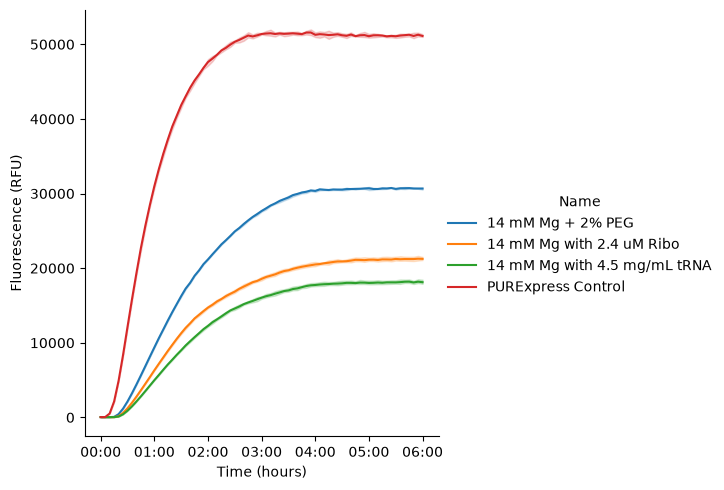

In [4]:
g = pr.plot_curves(data=data)
plt.savefig("g.png")

## Normalize Data

In [5]:
# No HPTS/fluorescein normalization control present in this platemap's Name column - skipping normalize_data_to_controls, using raw (unnormalized) data

Now replot your curves to see them normalized

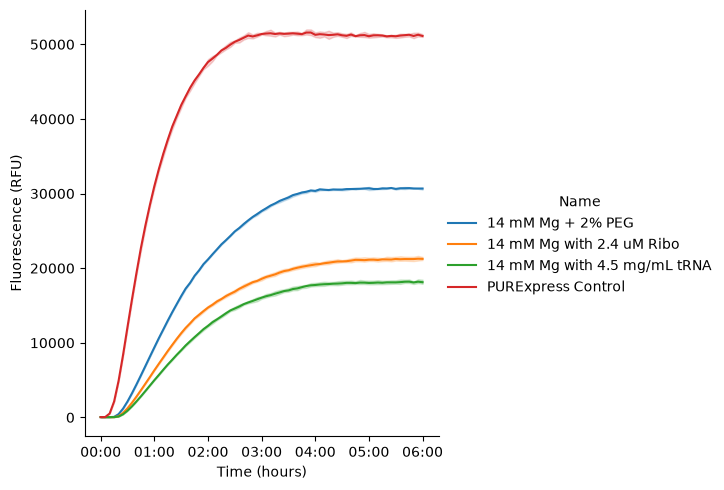

In [6]:
g = pr.plot_curves(data=data)

## Kinetic Analysis
**Metrics extracted:**

  - **Vmax** (`Velocity Max`): Maximum rate of fluorescence increase (slope at inflection point)
  - **Lag time**: Time to reach the exponential phase
  - **Steady-state**: Final fluorescence level and time to reach 95% of asymptote
  - **Drift**: Rate of signal decay or increase after steady-state
  - **R²**: Goodness of fit

In [7]:
# Perform kinetic analysis using sigmoid_drift model
kinetics = pr.kinetic_analysis(
    data=data,
    group_by=['Name'],  # Group by experimental condition
)

kinetics.head()

PROVIDING AVERAGED KINETICS


Velocity                    \
                                                  Time     Data      Max   
Name                                                                       
14 mM Mg + 2% PEG            0 days 01:15:50.930928051 15383.93 13231.25   
14 mM Mg with 2.4 uM Ribo    0 days 01:10:50.015513276 10646.53  8970.78   
14 mM Mg with 4.5 mg/mL tRNA 0 days 01:18:58.995220542  9146.66  7755.20   
PURExpress Control           0 days 00:47:43.129473711 25945.98 38477.03   

                                                     Lag           \
                                                    Time     Data   
Name                                                                
14 mM Mg + 2% PEG              0 days 00:06:05.210882700  -137.07   
14 mM Mg with 2.4 uM Ribo    -1 days +23:59:37.446228623 -1010.30   
14 mM Mg with 4.5 mg/mL tRNA   0 days 00:08:12.898738027  -174.28   
PURExpress Control             0 days 00:07:15.492622842  2256.61   

                                          Steady State           \
                                                  Time     Data   
Name                                                              
14 mM Mg + 2% PEG            0 days 02:58:33.229556189 29229.46   
14 mM Mg with 2.4 uM Ribo    0 days 02:55:40.175283837 20228.41   
14 mM Mg with 4.5 mg/mL tRNA 0 days 03:03:10.181215952 17378.65   
PURExpress Control           0 days 01:47:17.143758634 49297.35   

                                                                            Fit  \
                                                                         params   
Name                                                                              
14 mM Mg + 2% PEG             [30767.852418232796, 1.7201375348855346, 1.264...   
14 mM Mg with 2.4 uM Ribo     [21293.064278183123, 1.6852054404973302, 1.180...   
14 mM Mg with 4.5 mg/mL tRNA  [18293.31199335821, 1.6957841908660993, 1.3163...   
PURExpress Control            [51891.952471261844, 2.966322558923705, 0.7953...   

                                          
                              R^2  drift  
Name                                      
14 mM Mg + 2% PEG            1.00 768.35  
14 mM Mg with 2.4 uM Ribo    1.00 657.52  
14 mM Mg with 4.5 mg/mL tRNA 1.00 436.30  
PURExpress Control           1.00 748.86

## Visualize Fits on Individual Wells

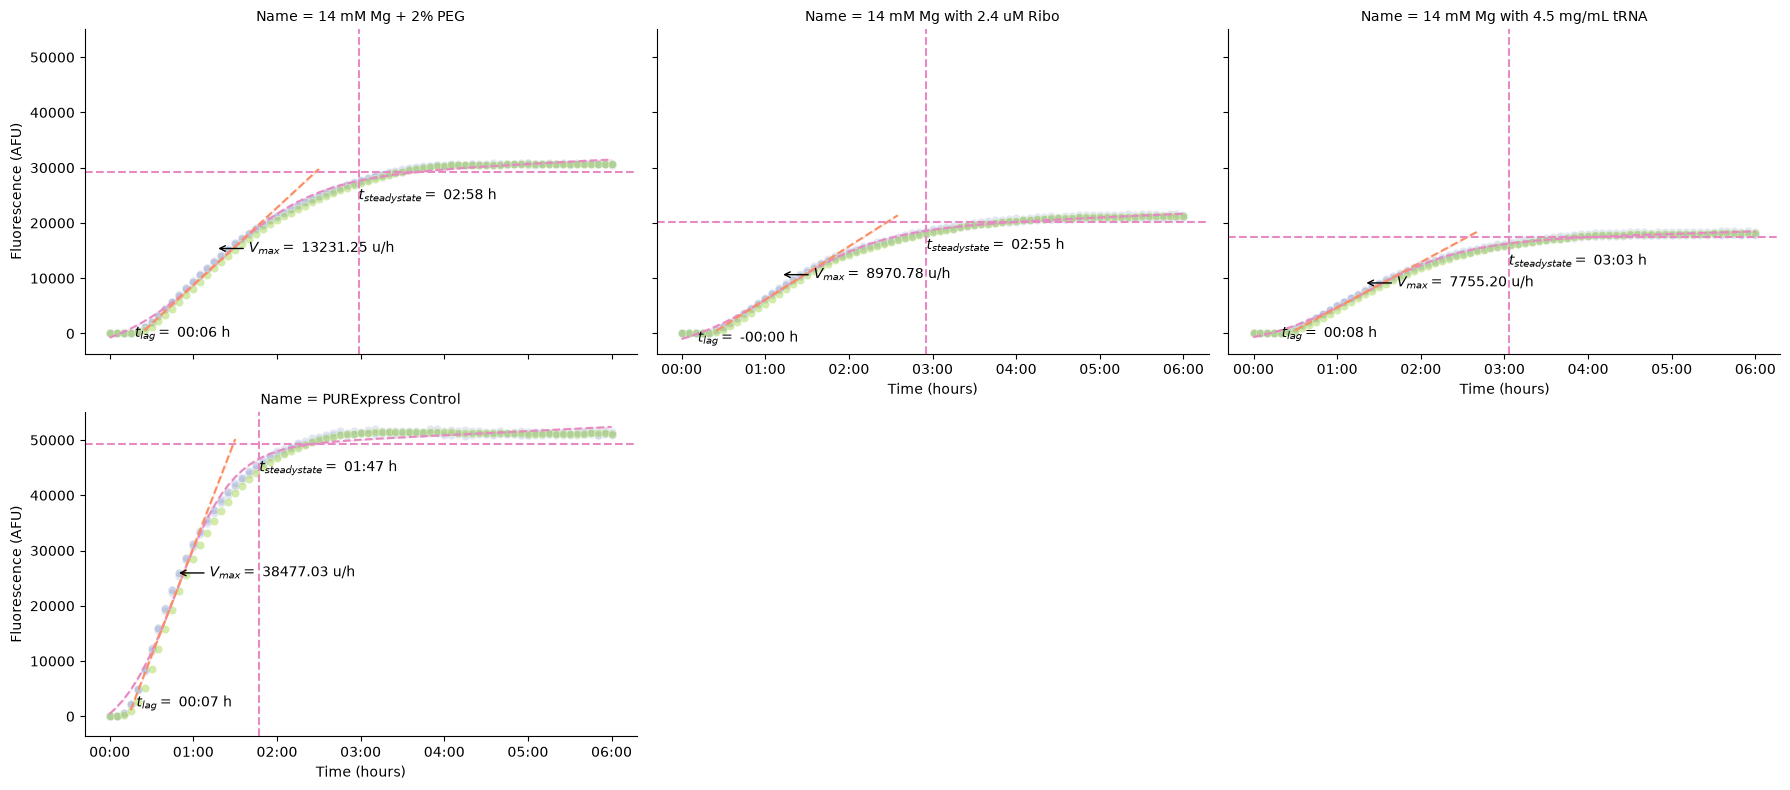

In [8]:
# Plot kinetic fits 
g = pr.plot_kinetics(data, kinetics=kinetics, group_by=["Name"])

## Summary Plots

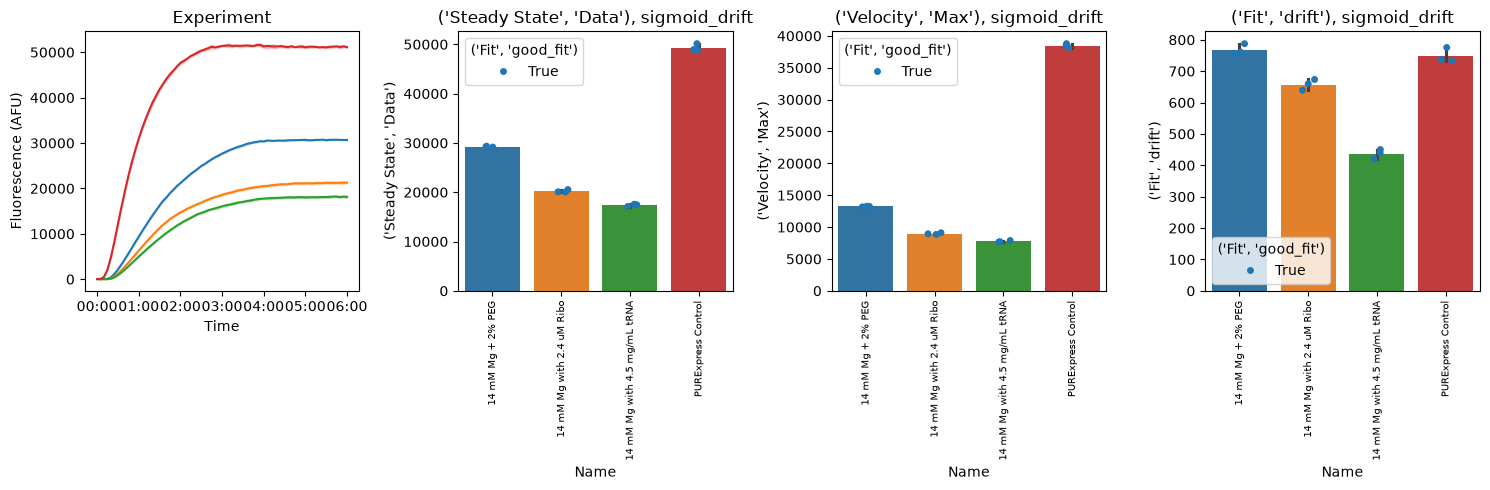

<Figure size 640x480 with 0 Axes>

In [9]:
summary_plot = pr.plot_summary(data)
plt.savefig("summary_plot.png")

---

## Key Metrics Explained

### 1. **Steady-State Level** (`Steady State, Data`)
- The final fluorescence value reached by the reaction
- Represents the total amount of protein produced
- Higher values indicate greater expression yield

### 2. **Maximum Velocity** (`Velocity, Max`)
- The steepest slope of the fluorescence curve (at the inflection point)
- Units: RFU per second
- Reflects the peak rate of protein synthesis
- Sensitive to enzyme activity, substrate availability, and reaction conditions

### 3. **Lag Time** (`Lag, Time`)
- Time before exponential fluorescence increase begins
- May reflect time for ribosome assembly or initial translation steps
- Shorter lag times suggest faster reaction initiation

### 4. **Drift** (`Fit, drift`)
- Rate of fluorescence change after reaching steady-state
- Positive drift: continued synthesis or aggregation
- Negative drift: photobleaching, protein degradation, or quenching
- Units: RFU per second

### 5. **R² Value** (`Fit, R^2`)
- Goodness of fit (0 to 1, higher is better)
- R² > 0.98 indicates excellent fit
- Poor fits may indicate noisy data, overflow errors, or non-sigmoid kinetics

---

## Tips and Troubleshooting

- **Overflow errors:** Wells with `OVRFLW` or `NaN` values are automatically excluded from fitting
- **Poor fits (low R²):** Inspect raw curves for anomalies (bubbles, evaporation, pipetting errors)
- **Drift:** Sometimes seen in kinetics curves; use `sigmoid_drift` model
- **Multiple replicates:** Always include technical replicates and report error bars
- **Comparing conditions:** Normalize or blank data consistently across all samples

---

## Next Steps

- Export kinetics results: `pr.export_kinetics(kinetics, 'results.csv')`
- Statistical analysis: Use `scipy.stats` or `statsmodels` for ANOVA/t-tests
- Parameter optimization: Vary Mg²⁺, K⁺, or other conditions to maximize Vmax or steady-state
- Mechanistic modeling: Fit ODE models to extract biological rate constants